### Initial Data Overview 

I begin by examining the structure of the dataset to understand the number of samples, features and class labels. This helps identify potential issues early, such as unexpected data types or columns irrelevant to modelling (e.g., ID fields). Understanding the dataset shape also informs later choices about model complexity and validation strategy because the dataset is relatively small. 

In [2]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


from sklearn.model_selection import train_test_split 

from sklearn.preprocessing import StandardScaler 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 

In [3]:
# Load the Breast Cancer Wisconsin (Diagnostic) Dataset 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data" 

columns = [ 

    'id','clump_thickness','uniformity_cell_size','uniformity_cell_shape', 

    'marginal_adhesion','single_epithelial_cell_size','bare_nuclei', 

    'bland_chromatin','normal_nucleoli','mitoses','class' 

] 

df = pd.read_csv(url, names=columns) 

df.head() 
df.shape 
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_cell_size         699 non-null    int64 
 3   uniformity_cell_shape        699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitoses                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


### Missing Values Analysis
The `bare_nuclei` feature contains “?” placeholders representing missing values. These are replaced with NaN and converted to numeric so they can be handled during preprocessing.

In [4]:
# Check original unique values 
df['bare_nuclei'].unique() 

# Replace '?' with NaN 
df['bare_nuclei'] = df['bare_nuclei'].replace("?", np.nan) 

# Convert to numeric 
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'], errors='coerce') 

# Count missing values 
df.isnull().sum() 

id                              0
clump_thickness                 0
uniformity_cell_size            0
uniformity_cell_shape           0
marginal_adhesion               0
single_epithelial_cell_size     0
bare_nuclei                    16
bland_chromatin                 0
normal_nucleoli                 0
mitoses                         0
class                           0
dtype: int64

In [5]:
# Check data types after convertion 
df.dtypes 

id                               int64
clump_thickness                  int64
uniformity_cell_size             int64
uniformity_cell_shape            int64
marginal_adhesion                int64
single_epithelial_cell_size      int64
bare_nuclei                    float64
bland_chromatin                  int64
normal_nucleoli                  int64
mitoses                          int64
class                            int64
dtype: object

### Class Distribution
A countplot shows the distribution of benign and malignant cases. The dataset is mildly imbalanced, with benign cases being more common. Stratified train-test splitting is used to preserve this distribution.

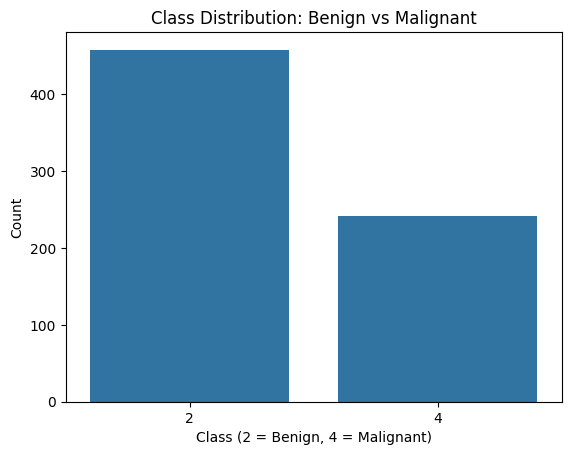

class
2    0.655222
4    0.344778
Name: proportion, dtype: float64

In [6]:
sns.countplot(x='class', data=df) 
plt.title('Class Distribution: Benign vs Malignant') 
plt.xlabel('Class (2 = Benign, 4 = Malignant)') 
plt.ylabel('Count') 
plt.show() 

df['class'].value_counts() 
df['class'].value_counts(normalize=True) 

### Statistical Summary
The summary statistics show different feature scales and some skewed distributions. This confirms that feature scaling is needed before training models such as SVM and k-NN.

In [7]:
df.describe() 

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


### Feature Distributions
Histograms show the distribution of each feature. Many variables are slightly right-skewed, and the results confirm the need for feature scaling during preprocessing.

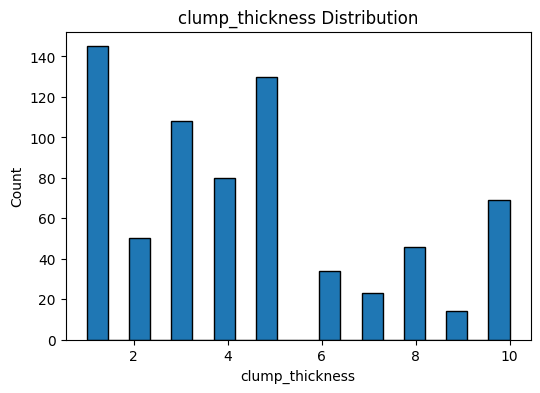

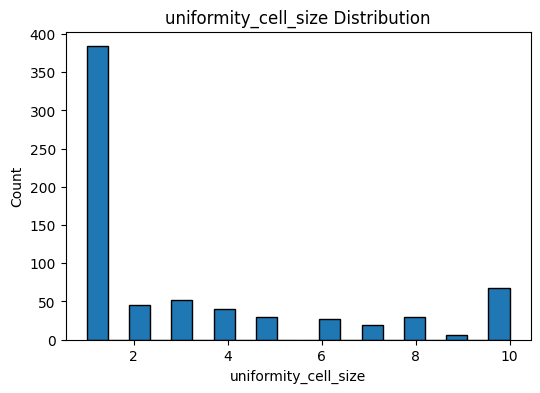

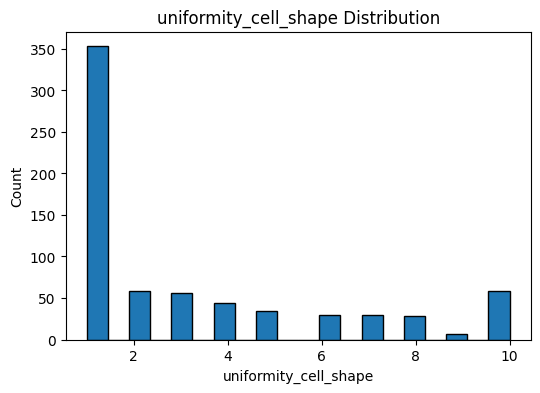

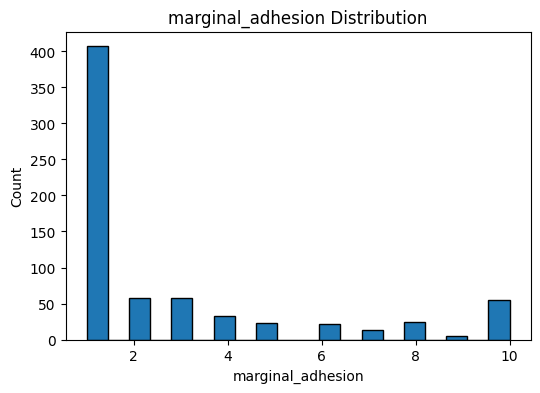

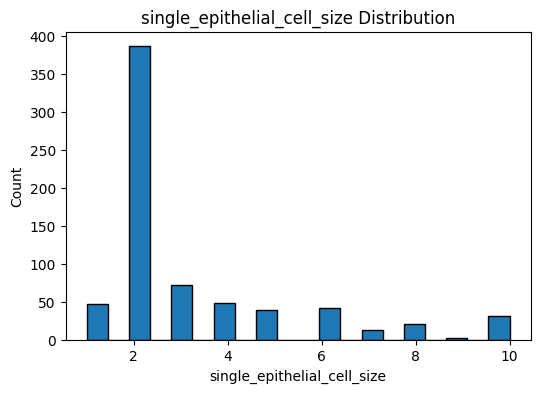

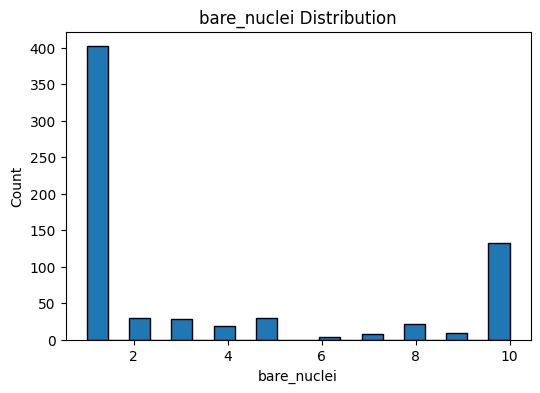

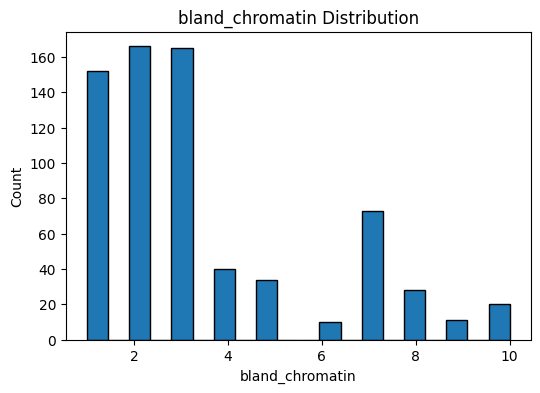

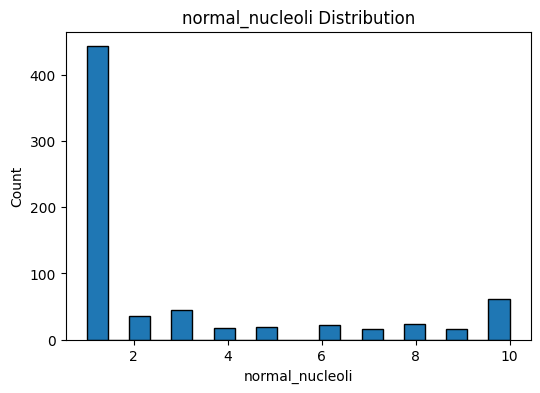

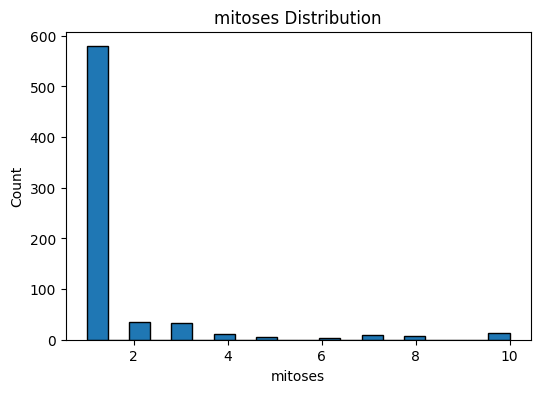

In [8]:
features = [ 
    'clump_thickness','uniformity_cell_size','uniformity_cell_shape', 
    'marginal_adhesion','single_epithelial_cell_size','bare_nuclei', 
    'bland_chromatin','normal_nucleoli','mitoses' 
] 

for col in features: 
    plt.figure(figsize=(6,4)) 
    plt.hist(df[col], bins=20, edgecolor='black') 
    plt.title(f'{col} Distribution') 
    plt.xlabel(col) 
    plt.ylabel('Count') 
    plt.show() 

### Feature Correlations
A correlation heatmap is used to examine relationships between features. The `id` column is removed as it has no predictive value, and missing values in `bare_nuclei` are imputed to ensure a complete correlation matrix.

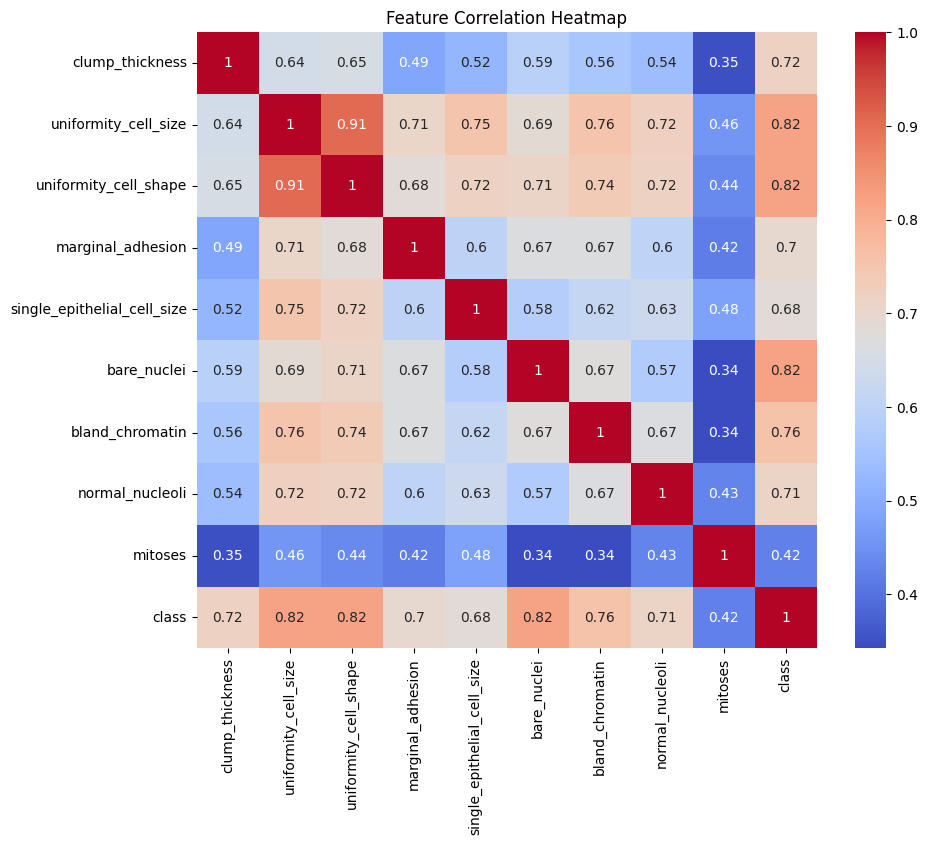

In [10]:
# Prepare dataframe for correlation: drop id and impute missing values 
df_corr = df.drop(columns=['id']).copy() 
df_corr['bare_nuclei'] = df_corr['bare_nuclei'].fillna(df_corr['bare_nuclei'].median()) 

plt.figure(figsize=(10,8)) 
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm') 
plt.title('Feature Correlation Heatmap') 
plt.show() 

### EDA Summary 
EDA shows the dataset contains 699 samples with mild class imbalance and missing values in the `bare_nuclei` feature. These issues are addressed during preprocessing. 

### Preparing Features and Target
The `id` column is removed and class labels are converted to binary values for model training.

In [11]:
# Remove ID column 
df_clean = df.drop(columns=['id']) 
# Map class labels to binary values 
df_clean['class'] = df_clean['class'].map({2: 0, 4: 1}) 

# Separate features and target 
X = df_clean.drop(columns=['class']) 
y = df_clean['class'] 

### Handling Missing Values
Missing values in `bare_nuclei` are handled using median imputation to maintain a complete dataset.

In [12]:
from sklearn.impute import SimpleImputer 

# Median imputer for numerical features 
imputer = SimpleImputer(strategy='median') 

# Fit on training data only, transform both sets later 
X_imputed = imputer.fit_transform(X) 

### Feature Scaling
Features have different numerical ranges, so scaling is required for models like SVM and k-NN. Standardisation (mean = 0, variance = 1) is applied after imputation.

In [13]:
# Standardise features 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X_imputed) 

### Train–Test Split
A stratified train-test split is used to preserve the class distribution between benign and malignant cases. An 80/20 split provides sufficient training data while keeping a reliable test set for evaluation.

In [14]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split( 

    X_scaled, y, test_size=0.2, random_state=42, stratify=y 
) 

In [15]:
print("Training set class distribution:") 
print(y_train.value_counts(normalize=True)) 

print("\nTest set class distribution:") 
print(y_test.value_counts(normalize=True)) 

Training set class distribution:
class
0    0.654741
1    0.345259
Name: proportion, dtype: float64

Test set class distribution:
class
0    0.657143
1    0.342857
Name: proportion, dtype: float64


### Verification 
After preprocessing, the dataset contains no missing values, consistent scaling across features, and a balanced class distribution across train and test sets.

In [16]:
# Confirm shapes 
X_train.shape, X_test.shape, y_train.shape, y_test.shape 


# Confirm no missing values 
np.isnan(X_train).sum(), np.isnan(X_test).sum() 

(0, 0)

### Logistic Regression (Baseline Model)
Logistic Regression is used as a simple baseline model for comparison with more complex classifiers.

In [49]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import roc_auc_score

print("### Logistic Regression Results ###") 

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print("Train accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test accuracy:", accuracy_score(y_test, y_test_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
    print("Classification report:\n", classification_report(y_test, y_test_pred))


log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


evaluate_model(log_reg, X_train, X_test, y_train, y_test) 
y_probs = log_reg.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_probs))

### Logistic Regression Results ###
Train accuracy: 0.9731663685152058
Test accuracy: 0.95
Confusion matrix:
 [[89  3]
 [ 4 44]]
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96        92
           1       0.94      0.92      0.93        48

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140

ROC AUC: 0.995018115942029


### k-Nearest Neighbours
k-NN is a distance-based model that requires feature scaling. Several values of k were tested, with k=9 providing stable results.

In [47]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import roc_auc_score

knn = KNeighborsClassifier(n_neighbors=9) 
knn.fit(X_train, y_train) 


print("### k-NN Results ###") 
evaluate_model(knn, X_train, X_test, y_train, y_test) 

y_probs = knn.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_probs)
print("ROC AUC:", roc_auc)

### k-NN Results ###
Train accuracy: 0.9731663685152058
Test accuracy: 0.9571428571428572
Confusion matrix:
 [[89  3]
 [ 3 45]]
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        92
           1       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140

ROC AUC: 0.9763360507246376


In [48]:
for k in [3, 5, 7, 9]: 

    knn = KNeighborsClassifier(n_neighbors=k) 
    knn.fit(X_train, y_train) 
    print(f"k={k}, Test Accuracy={accuracy_score(y_test, knn.predict(X_test)):.4f}") 

 

k=3, Test Accuracy=0.9429
k=5, Test Accuracy=0.9429
k=7, Test Accuracy=0.9500
k=9, Test Accuracy=0.9571


### Support Vector Machine (RBF)
SVM with an RBF kernel is used to capture non-linear relationships between features. Default hyperparameters (C=1.0, gamma='scale') are used to balance model flexibility and generalisation.

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(X_train, y_train)

print("### SVM (RBF) Results ###")
evaluate_model(svm_model, X_train, X_test, y_train, y_test)

y_probs = svm_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_probs)

print("ROC AUC:", roc_auc)

### SVM (RBF) Results ###
Train accuracy: 0.9785330948121646
Test accuracy: 0.9571428571428572
Confusion matrix:
 [[89  3]
 [ 3 45]]
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        92
           1       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140

ROC AUC: 0.9898097826086957


### Random Forest
Random Forest is an ensemble model that captures complex feature interactions and reduces variance by averaging multiple decision trees.

In [38]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42) 
rf.fit(X_train, y_train) 

print("### Random Forest Results ###") 
evaluate_model(rf, X_train, X_test, y_train, y_test) 


y_probs = rf.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_probs)

print("ROC AUC:", roc_auc)

### Random Forest Results ###
Train accuracy: 1.0
Test accuracy: 0.9571428571428572
Confusion matrix:
 [[88  4]
 [ 2 46]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        92
           1       0.92      0.96      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.96      0.95       140
weighted avg       0.96      0.96      0.96       140

ROC AUC: 0.9887907608695652


### SVM Hyperparameter Exploration
Grid search with 5-fold cross-validation was used to explore different values of C and gamma for the RBF SVM. The best parameters were selected based on cross-validation accuracy. Although the tuned model achieved strong performance, it did not outperform the default SVM on the test set.

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'probability': [True]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_svm = grid.best_estimator_

print("Best parameters found:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

print("### Tuned SVM Results ###")
evaluate_model(best_svm, X_train, X_test, y_train, y_test)

y_probs = best_svm.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probs)
print("ROC AUC:", roc_auc)

results = pd.DataFrame(grid.cv_results_)
results[['param_C', 'param_gamma', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head()

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf', 'probability': True}
Best cross-validation accuracy: 0.9660392535392536
### Tuned SVM Results ###
Train accuracy: 0.9660107334525939
Test accuracy: 0.95
Confusion matrix:
 [[89  3]
 [ 4 44]]
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96        92
           1       0.94      0.92      0.93        48

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140

ROC AUC: 0.993659420289855


,param_C,param_gamma,mean_test_score
1,0.1,0.01,0.966039
6,1.0,0.1,0.966007
5,1.0,0.01,0.966007
0,0.1,scale,0.964221
2,0.1,0.1,0.964221


### Model Comparison
The performance of all models is compared using test accuracy, recall for malignant cases, and ROC AUC. These metrics provide a balanced evaluation of overall performance and the ability to correctly identify malignant cases.

In [45]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

results = []

models = {
    "Logistic Regression": log_reg,
    "k-NN": knn,
    "SVM": svm_model,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (Malignant)": recall_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Recall (Malignant),ROC AUC
0,Logistic Regression,0.950000,0.916667,0.995018
1,k-NN,0.942857,0.916667,0.973958
2,SVM,0.957143,0.937500,0.989810
3,Random Forest,0.957143,0.958333,0.988791


### Model Performance Visualisation
This plot compares the test accuracy of each model, highlighting the relative performance differences between the classifiers.

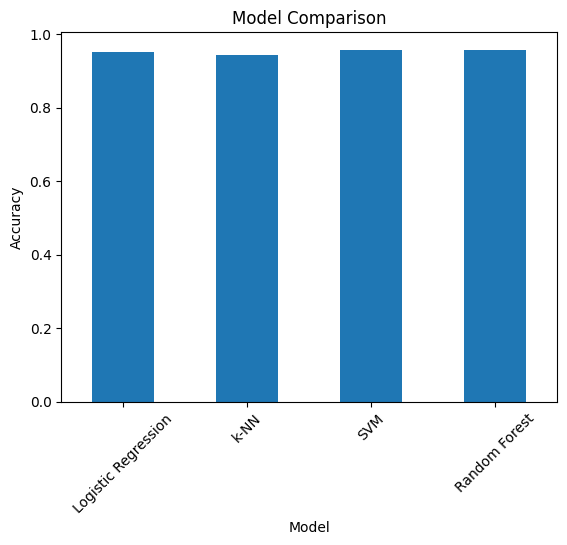

In [46]:
import matplotlib.pyplot as plt

results_df.set_index("Model")["Accuracy"].plot(kind="bar")

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()